# NLP Sentiment Analysis Project — EDA & Feature Engineering
### Project Title
## Sentiment Analysis on Customer Reviews using NLP

#1. Business Objective
The objective of this project is to analyze customer reviews and automatically determine the sentiment
behind them.
##The project aims to:
* Understand customer opinions from textual reviews
* Classify reviews into positive, negative, or neutral sentiments
* Help businesses make data-driven decisions using customer feedback
* Build a scalable NLP pipeline that can later be deployed using Streamlit/ Flask/RShiny

#2. Problem Statement
E-commerce platforms receive thousands of customer reviews daily. Manually reading and analyzing these reviews is inefficient and time-consuming.
##Using Natural Language Processing (NLP), we can:
* Extract meaningful insights from reviews
* Identify customer satisfaction patterns
* Automate sentiment classification
* Improve customer experience and product quality

#3. Dataset Information
##Dataset contains customer reviews with:


Title :    Review title

Rating Product :     rating given by customer

Body :    Detailed customer review

#Dataset Shape:
Rows: 1440

Columns: 3

# 4. Import Required Libraries

In [340]:
pip install WordCloud

Note: you may need to restart the kernel to use updated packages.


In [408]:
# Data Handling
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# NLP Libraries
import sklearn
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
# Word Cloud
from wordcloud import WordCloud
# Feature Engineering
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')


# 5. Download NLP Resources

In [409]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Neha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Neha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Neha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Neha\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Neha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 6. Load Dataset

In [410]:
import pandas as pd

_df = pd.read_excel('D:\\Projects Data Science\\Project on NLP\\Sentiment Analysis Dataset.xlsx')
_df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


# 7. Basic Data Understanding



In [411]:
#7.1 Dataset Shape
print('Dataset Shape:', _df.shape)

Dataset Shape: (1440, 3)


# Explanation
##shape returns:
Number of rows
Number of columns
##Example:
(1440, 3)
means:

1440 records
3 columns

In [412]:
#7.2 Column Names
print(_df.columns)


Index(['title', 'rating', 'body'], dtype='object')


# Explanation
This helps understand available features in the dataset.

In [413]:
#7.3 Dataset Information
_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


# Explanation
##.info() gives:
1. Data types
2. Null values
3. Memory usage
4. Non-null counts
5. Industry Importance: This is the first thing data scientists inspect before any preprocessing.

In [414]:
# 7.4 Statistical Summary
_df.describe(include='all')


,title,rating,body
count,1440,1440.000000,1440
unique,1351,NaN,1440
top,Value for money,NaN,Very disappointed with the overall performance...
freq,16,NaN,1
mean,NaN,3.173611,NaN
std,NaN,1.584453,NaN
min,NaN,1.000000,NaN
25%,NaN,1.000000,NaN
50%,NaN,4.000000,NaN
75%,NaN,5.000000,NaN


# Explanation
##This helps understand:
1. Distribution of ratings
2. Unique values
3. Most frequent values
4. Frequency counts

# 8. Missing Value Analysis


In [415]:
# Check null values
null_values = _df.isnull().sum()
print(null_values)

title     0
rating    0
body      0
dtype: int64


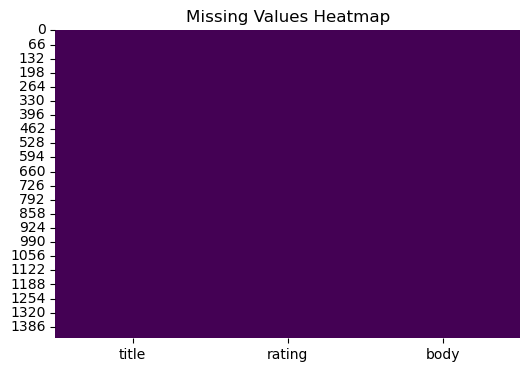

In [416]:
# Visualization
plt.figure(figsize=(6,4))
sns.heatmap(_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# Explanation
1. Missing values reduce model quality
2. Heatmap visually identifies missing data patterns
3. In industry projects, missing data handling is mandatory

# 9. Duplicate Value Analysis

In [417]:
# Check duplicates
duplicates = _df.duplicated().sum()
print('Duplicate Rows:', duplicates)

Duplicate Rows: 0


# Explanation
Duplicate reviews can bias the sentiment model. Removing them improves data quality.But, here we see are no duplicates in this dataset.


# 10. Feature Creation
##Combine Title and Body

###Why We Do This
Instead of analyzing title and body separately:
1. We merge both into one meaningful review text
2. Gives better context to NLP models
3. Improves sentiment understanding
###Example:
##Before:
Title: Horrible Product

Body: Very disappointed with performance

After: Horrible Product Very disappointed with performance

In [418]:
_df['review'] = _df['title'].astype(str) + ' ' + _df['body'].astype(str)

# 11. Target Variable Creation
Convert Ratings into Sentiment Labels

In [419]:
# Create sentiment column
def sentiment_label(rating):
  if rating >= 4:
   return 'Positive'
  elif rating == 3:
   return 'Neutral'
  else:
   return 'Negative'
_df['sentiment'] = _df['rating'].apply(sentiment_label)

# Explanation
##Ratings are converted into sentiment classes:
##Rating Sentiment
* 4,5 Positive
* 3 Neutral
* 1,2 Negative
##Industry Logic:
* High ratings indicate satisfaction
* Medium rating indicates mixed opinion
* Low ratings indicate dissatisfaction

# 12. Sentiment Distribution Analysis

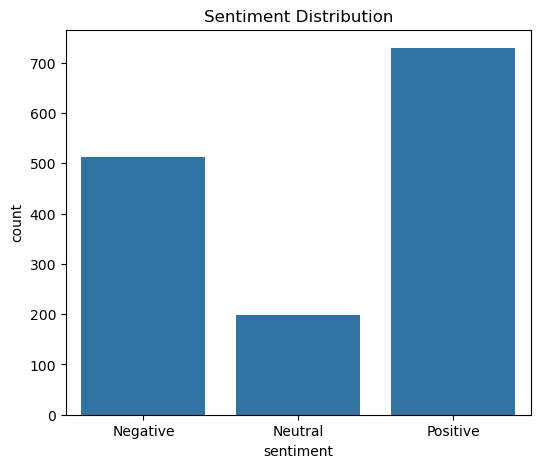

In [420]:
plt.figure(figsize=(6,5))
sns.countplot(x='sentiment', data=_df)
plt.title('Sentiment Distribution')
plt.show()


# Explanation
###This helps identify:
1. Class imbalance
2. Dataset bias
3. Whether model training may favor one class
4. Important in Machine Learning because:
5. Imbalanced data leads to biased predictions

# 13. Rating Distribution

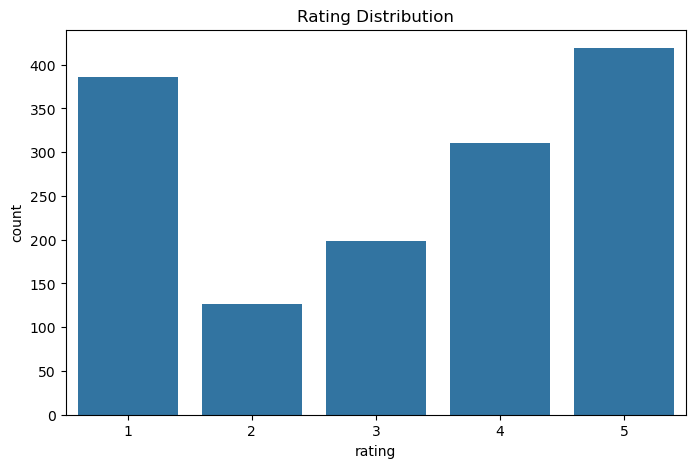

In [421]:
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=_df)
plt.title('Rating Distribution')
plt.show()


# Insight
##This helps understand:
1. Most common customer rating
2. Overall customer satisfaction trend

# 14. Review Length Analysis

In [422]:
# Create Review Length Feature
_df['review_length'] = _df['review'].apply(len)

# Explanation
This feature stores total number of characters in each review.
##Industry Importance: Long reviews often contain:
1. Detailed feedback
2. Strong sentiment
3. Better contextual information

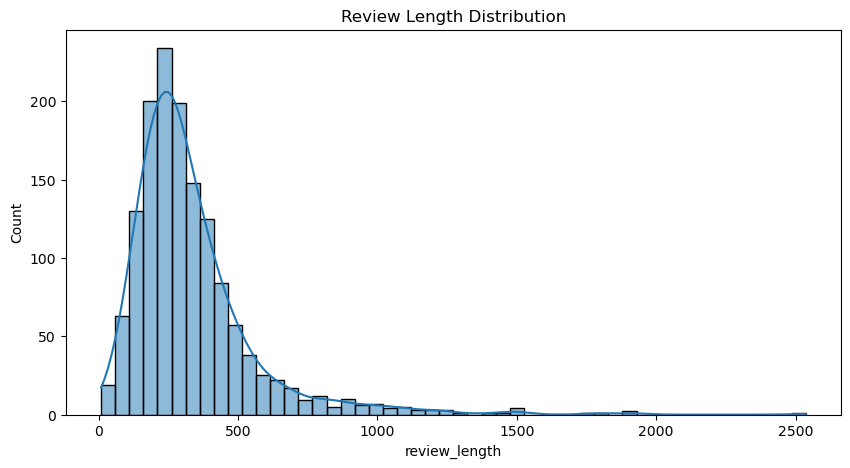

In [423]:
# Distribution of Review Length
plt.figure(figsize=(10,5))
sns.histplot(_df['review_length'], bins=50, kde=True)
plt.title('Review Length Distribution')
plt.show()


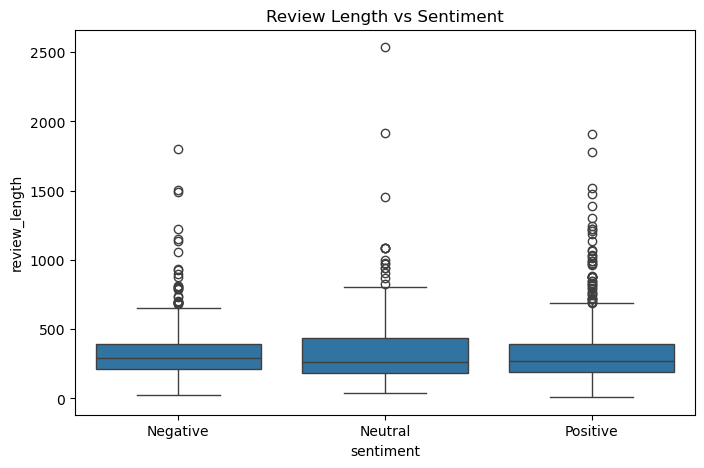

In [424]:
# Review Length vs Sentiment
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='review_length', data=_df)
plt.title('Review Length vs Sentiment')
plt.show()

# Insight
##This helps understand whether:
1. Negative reviews are longer
2. Positive reviews are shorter
3. Neutral reviews are balanced
4. Real-world observation: Unhappy customers usually write longer detailed complaints.

# 15. Text Preprocessing
Text preprocessing is the most important stage in NLP.
##Raw text contains:
* Punctuation
* URLs
* Emojis
* Stopwords
* Uppercase/lowercase inconsistencies
* Noise
* Cleaning improves model performance significantly.


In [425]:
# 16. Initialize NLP Objects
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [426]:
# 17. Text Cleaning Function
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    cleaned_tokens = []
    for word in tokens:
        if word not in stop_words:
            lemma_word = lemmatizer.lemmatize(word)
            cleaned_tokens.append(lemma_word)
    # Join words back
    cleaned_text = ' '.join(cleaned_tokens)
    return cleaned_text

# 18. Apply Cleaning Function

In [427]:
_df['cleaned_review'] = _df['review'].apply(clean_text)

# 19. Compare Original vs Cleaned **Text**

In [428]:
comparison = _df[['review', 'cleaned_review']].head()
print(comparison)

                                              review  \
0  Horrible product Very disappointed with the ov...   
1  Camera quality is not like 48 megapixel Camera...   
2  Overall Got the mobile on the launch date,Batt...   
3  A big no from me 1. It doesn't work with 5.0GH...   
4  Put your money somewhere else Not worth buying...   

                                      cleaned_review  
0  horrible product disappointed overall performa...  
1   camera quality like megapixel camera quality low  
2  overall got mobile launch datebattery must app...  
3  big doesnt work ghz wifi frequency ghz old sch...  
4  put money somewhere else worth buyingfaulty so...  


# 20. Word Frequency Analysis

In [429]:
# Create Corpus
all_words = ' '.join(_df['cleaned_review'])

In [430]:
# Most Common Words
from collections import Counter
word_list = all_words.split()
word_freq = Counter(word_list)
common_words = word_freq.most_common(20)
common_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
print(common_df)

       Word  Frequency
0     phone       1911
1      good       1354
2    camera        980
3   battery        804
4   samsung        747
5   quality        699
6    mobile        613
7     price        441
8   product        436
9       day        359
10      buy        336
11     also        308
12     life        304
13  display        298
14     like        291
15     dont        279
16      one        263
17   better        253
18      use        252
19   screen        243


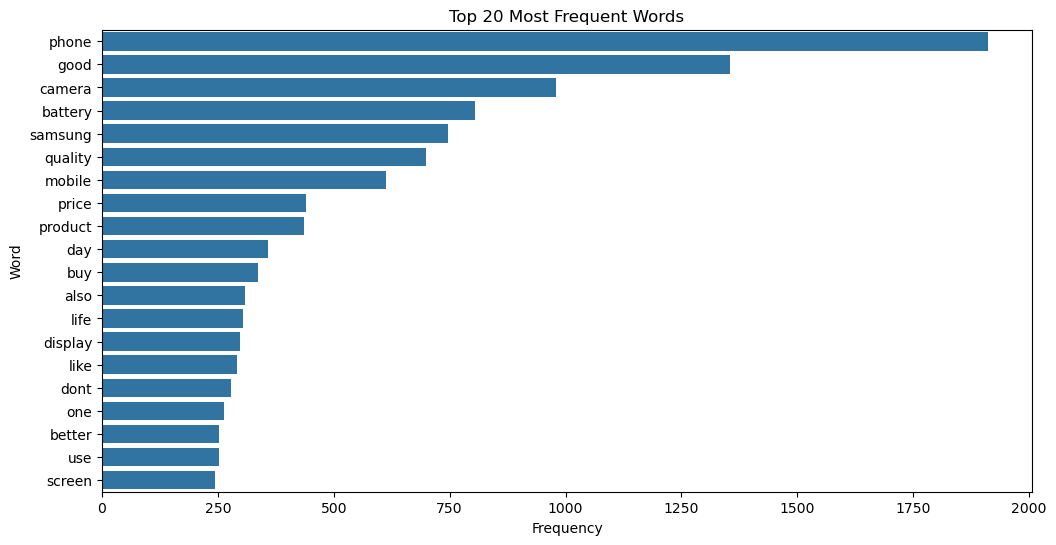

In [431]:
# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x='Frequency', y='Word', data=common_df)
plt.title('Top 20 Most Frequent Words')
plt.show()

# Insight
###This helps identify:
* Most discussed topics
* Frequently repeated complaints
* Important customer concerns

# 21. WordCloud Visualization

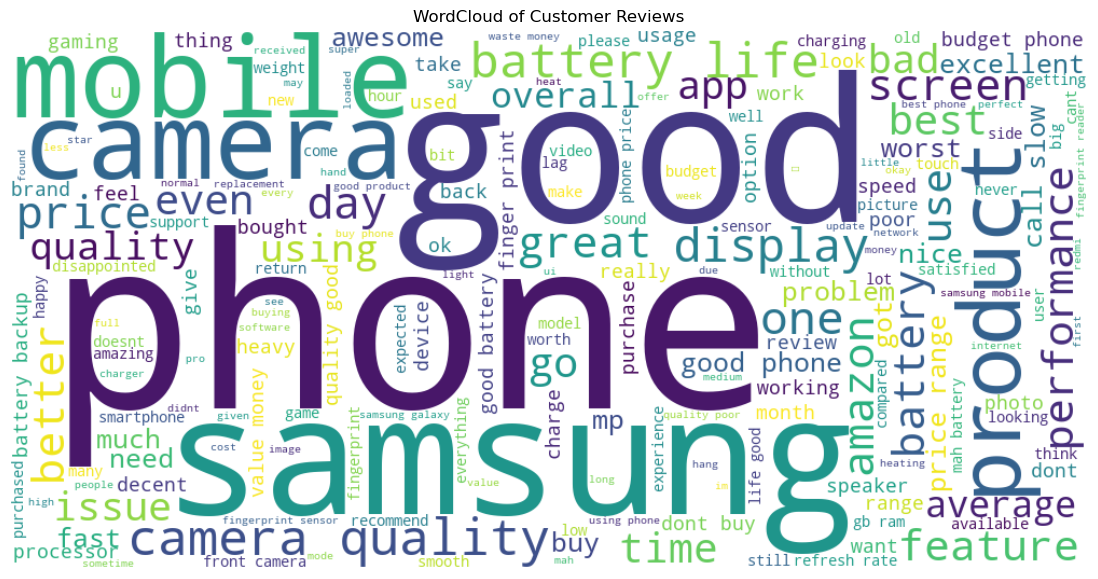

In [432]:
wordcloud = WordCloud(
width=1000,
height=500,
background_color='white'
).generate(all_words)
plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Customer Reviews')
plt.show()

# Explanation
###WordCloud visually represents:
1. Frequently occurring words
2. Important review themes
3. Dominant customer opinions
4. Larger words = higher frequency.


# 22. Positive and Negative WordClouds

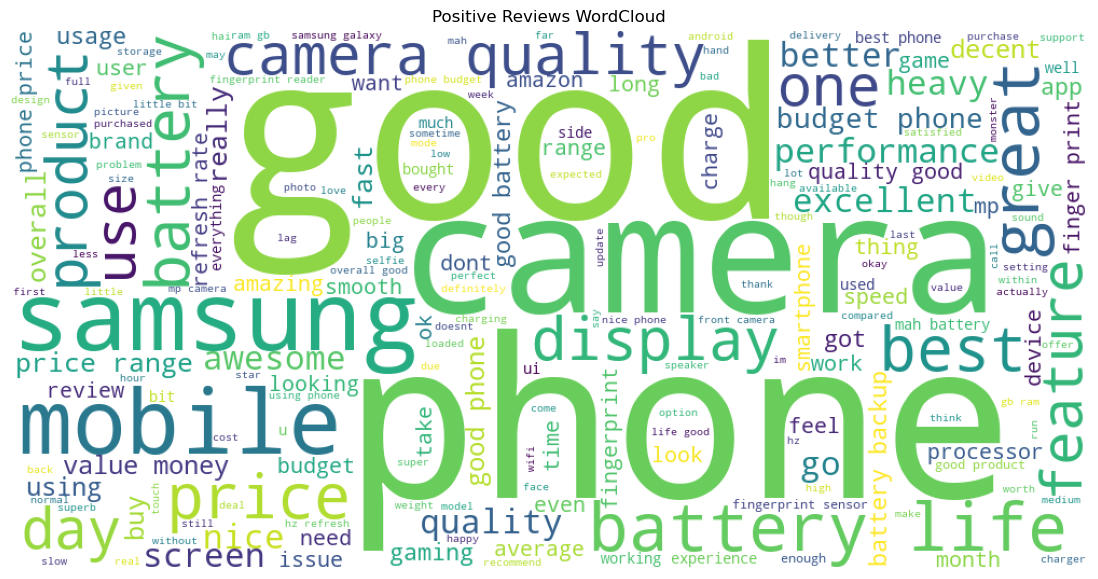

In [433]:
# Positive Reviews
positive_reviews = ' '.join(
_df[_df['sentiment'] == 'Positive']['cleaned_review']
)
positive_wc = WordCloud(
width=1000,
height=500,
background_color='white'
).generate(positive_reviews)
plt.figure(figsize=(15,7))
plt.imshow(positive_wc)
plt.axis('off')
plt.title('Positive Reviews WordCloud')
plt.show()

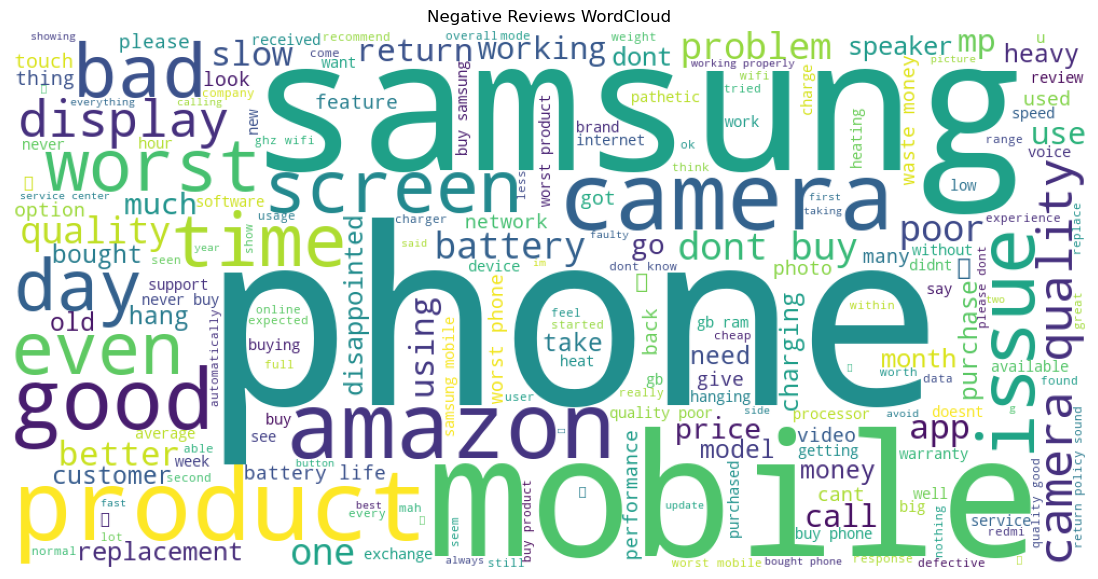

In [434]:
# Negative Reviews
negative_reviews = ' '.join(
_df[_df['sentiment'] == 'Negative']['cleaned_review']
)
negative_wc = WordCloud(
width=1000,
height=500,
background_color='white'
).generate(negative_reviews)
plt.figure(figsize=(15,7))
plt.imshow(negative_wc)
plt.axis('off')
plt.title('Negative Reviews WordCloud')
plt.show()

# 23. Feature Engineering
Feature engineering converts text into machine-readable numerical format.
Machine Learning models cannot understand raw text directly.
We transform text into vectors

# 24. Bag of Words (BoW)
###What is Bag of Words?
BoW converts text into frequency counts.
###Example:
15
###Sentence 1:
phone is good
###Sentence 2:
phone is bad
###Vocabulary:
phone
good
bad
###Vector Representation:
###Sentence
1. phone is good: 1 1 0
2. phone is bad: 1 0 1


In [435]:
# Implement CountVectorizer
bow = CountVectorizer(max_features=3000)
X_bow = bow.fit_transform(_df['cleaned_review'])

# Explanation
* max_features=3000
* Keeps top 3000 important words
* Reduces dimensionality
* Prevents overfitting

In [436]:
# Shape of BoW Matrix
print(X_bow.shape)

(1440, 3000)


# Meaning:
Rows = reviews

Columns = vocabulary words/features

# 26. TF-IDF Vectorization
###Why TF-IDF?
Bag of Words only counts frequency.

**Problem:** Common words may dominate.
###TF-IDF solves this by:
Giving higher importance to unique informative words
Reducing importance of extremely common words
Formula Concept

TF = Term Frequency

IDF = Inverse Document Frequency

TF-IDF Score = TF × IDF

Words appearing in many documents get lower weight

In [437]:
# Implement TF-IDF
tfidf = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf.fit_transform(_df['cleaned_review'])

In [438]:
# Shape of TF-IDF Matrix
print(X_tfidf.shape)

(1440, 3000)


# 26. Why is TF-IDF better than (BoW)
# | Bag of Words (BoW)    | TF-IDF                        |

| --------------------- | ----------------------------- |

| Counts frequency only | Uses weighted importance      |

| Common words dominate | Reduces common word influence |

| Simpler               | More intelligent weighting    |

| Lower performance     | Better NLP performance        |


# Industry Standard: TF-IDF is widely used in sentiment analysis.

# 27. Additional Feature Engineering Ideas
These can be added later for advanced modeling:
1. Word Count


`_df['word_count'] = _df['cleaned_review'].apply(lambda x: len(x.split()))`
2. Average Word Length
```
_df['avg_word_length'] = _df['cleaned_review'].apply(
lambda x: np.mean([len(word) for word in x.split()])
)

```





3. Exclamation Count
```
_df['exclamation_count'] = _df['review'].apply(lambda x: x.count('!'))
```
###Why Useful?
More exclamations often indicate strong emotions
Longer reviews may indicate stronger sentiment
These handcrafted features improve model learning.

In [439]:
# 28 Save Processed Dataset
_df.to_csv('processed_sentiment_data.csv', index=False)

# Why Important?
This saves preprocessing work. Later stages can directly use cleaned dataset.

# 28. Key Insights from EDA
###Business Insights
1. Customer reviews contain strong sentiment patterns.
2. Negative reviews tend to be more detailed.
3. Positive reviews are more frequent than neutral reviews.
4. Word frequency analysis highlights major customer concerns.
5. Text preprocessing significantly improves data quality.


# 29. Conclusion
###In this phase we completed:
* Data understanding
* Missing value analysis
* Duplicate analysis
* Sentiment label creation
* Review length analysis
* Text preprocessing
* Word frequency analysis
* WordCloud visualization
* Bag of Words feature engineering
* TF-IDF feature
* Engineering Processe

# This dataset is now ready for:
1. Model building
2. Model evaluation
3. Sentiment prediction
4. Deployment

#30.Train-Test Split
###The reason for train-test split

We must evaluate the model on unseen data.

Standard Practice

In [440]:
# preparing for train and test split
X = X_tfidf

y = _df['sentiment']

In [441]:
# train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,
    stratify=y)

#31. Model Building
###Model 1 – Multinomial Naive Bayes

In [442]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train,y_train)
nb_pred = nb_model.predict(X_test)

###Model 2 – Logistic Regression

In [443]:
from sklearn.linear_model import LogisticRegression
lr_model =LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

###Model 3 – Random Forest

In [444]:
from sklearn.ensemble import RandomForestClassifier
rf_model =RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred= rf_model.predict(X_test)

###Model 4-SVM

In [445]:
from sklearn.svm import SVC

svm_model = SVC(kernel='linear',C=1,class_weight='balanced',random_state=42)
svm_model.fit(X_train, y_train)
svm_pred= svm_model.predict(X_test)

# 32. Model Evaluation

###Metrics: Accuracy, Precision, Recall and F1 Score.

# Evaluate Naive Bayes

In [446]:
# Evaluation libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [447]:
# Evaluating Naive Bayes
nb_accuracy = accuracy_score(y_test, nb_pred)

nb_precision = precision_score(
    y_test,
    nb_pred,
    average='weighted'
)

nb_recall = recall_score(
    y_test,
    nb_pred,
    average='weighted'
)

nb_f1 = f1_score(
    y_test,
    nb_pred,
    average='weighted'
)

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Accuracy : 0.7361111111111112
Precision: 0.648011982570806
Recall   : 0.7361111111111112
F1 Score : 0.677926267281106


In [448]:
# Classification report
print(classification_report(
    y_test,
    nb_pred
))

              precision    recall  f1-score   support

    Negative       0.83      0.69      0.75       102
     Neutral       0.00      0.00      0.00        40
    Positive       0.70      0.97      0.81       146

    accuracy                           0.74       288
   macro avg       0.51      0.55      0.52       288
weighted avg       0.65      0.74      0.68       288



# Explanation

###Classification report provides:

1. Precision
2. Recall
3. F1 Score
4. Support

for each sentiment class.

In [449]:
# Confusion Matrix
cm_nb = confusion_matrix(
    y_test,
    nb_pred
)

print(cm_nb)

[[ 70   0  32]
 [ 10   0  30]
 [  4   0 142]]


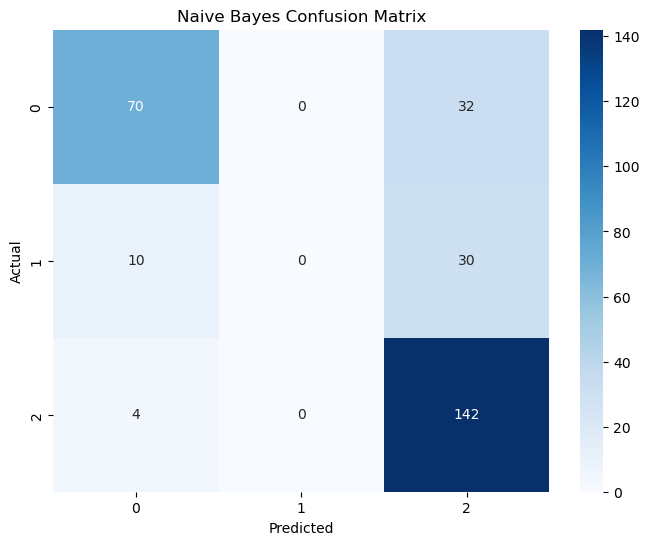

In [450]:
# Visualize confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Naive Bayes Confusion Matrix'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# Evaluate logistic Regression

In [451]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average='weighted'
)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.7743055555555556
Precision: 0.7396573493556252
Recall   : 0.7743055555555556
F1 Score : 0.7277034049218601


In [452]:
# Logistic Regression Classification Report
print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

    Negative       0.78      0.84      0.81       102
     Neutral       0.50      0.05      0.09        40
    Positive       0.78      0.92      0.84       146

    accuracy                           0.77       288
   macro avg       0.69      0.61      0.58       288
weighted avg       0.74      0.77      0.73       288



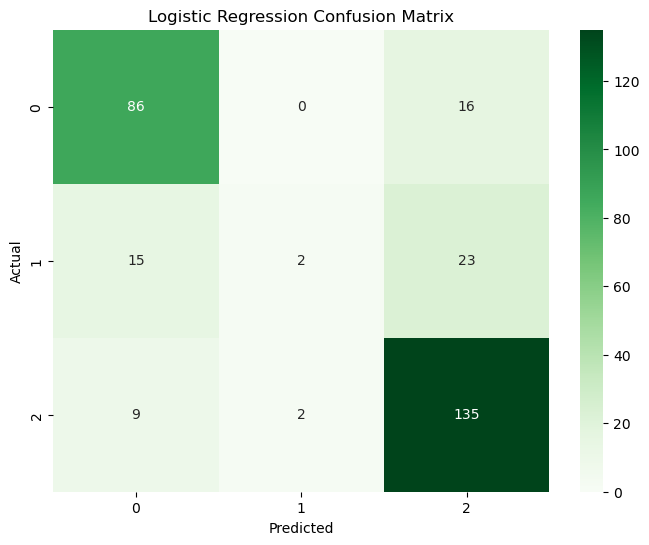

In [453]:
# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Logistic Regression Confusion Matrix'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# Evaluate Random Forest

In [454]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average='weighted'
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average='weighted'
)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.7534722222222222
Precision: 0.7868462911235258
Recall   : 0.7534722222222222
F1 Score : 0.7011431996188094


In [455]:
# Random Forest Classification Report
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

    Negative       0.75      0.79      0.77       102
     Neutral       1.00      0.03      0.05        40
    Positive       0.75      0.92      0.83       146

    accuracy                           0.75       288
   macro avg       0.83      0.58      0.55       288
weighted avg       0.79      0.75      0.70       288



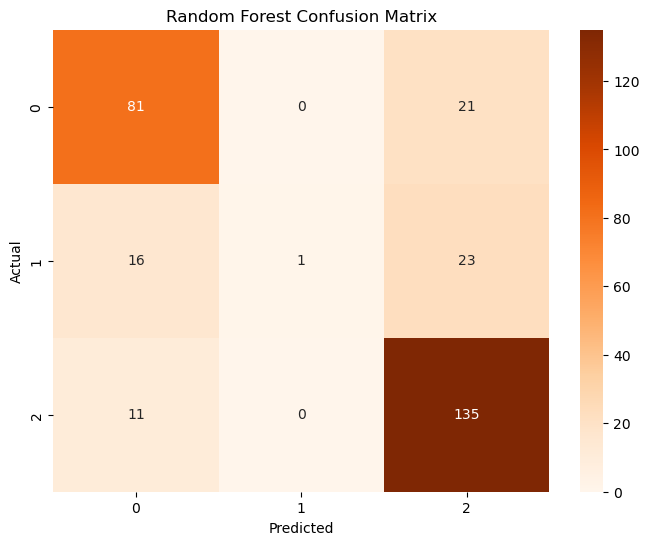

In [456]:
# Random Forest Confusion Matrix
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title(
    'Random Forest Confusion Matrix'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# Evaluate Support Vector Machine

In [457]:
svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_precision = precision_score(
    y_test,
    svm_pred,
    average='weighted'
)

svm_recall = recall_score(
    y_test,
    svm_pred,
    average='weighted'
)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average='weighted'
)

print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

Accuracy : 0.7430555555555556
Precision: 0.7526704240472356
Recall   : 0.7430555555555556
F1 Score : 0.7473148781864247


In [458]:
# Support Vector Classification Report
print(classification_report(
    y_test,
    svm_pred
))

              precision    recall  f1-score   support

    Negative       0.80      0.82      0.81       102
     Neutral       0.31      0.35      0.33        40
    Positive       0.84      0.79      0.82       146

    accuracy                           0.74       288
   macro avg       0.65      0.66      0.65       288
weighted avg       0.75      0.74      0.75       288



Text(70.72222222222221, 0.5, 'Actual')

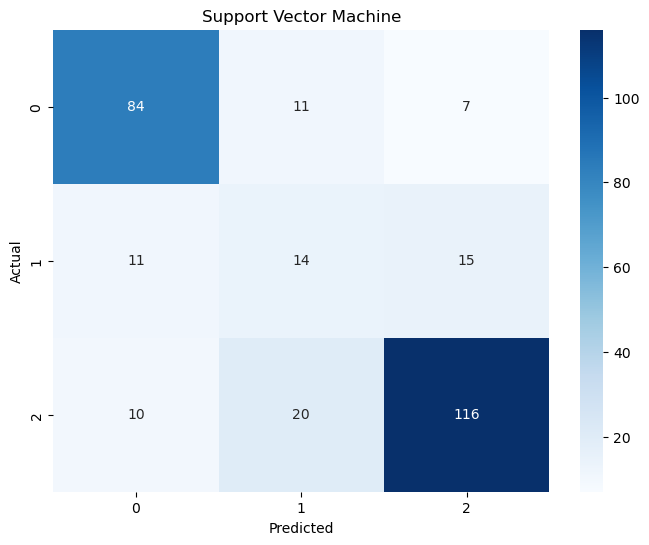

In [459]:
# Support Vector Machine
cm_svm = confusion_matrix(
    y_test,
    svm_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Support Vector Machine'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

# Model Comparision

In [460]:
# Create comparision Dataframe
comparison_df = pd.DataFrame({

    'Model':[
        'Naive Bayes',
        'Logistic Regression',
        'Random Forest',
        'Support Vector Machine'
    ],

    'Accuracy':[
        nb_accuracy,
        lr_accuracy,
        rf_accuracy,
        svm_accuracy
    ],

    'Precision':[
        nb_precision,
        lr_precision,
        rf_precision,
        svm_precision
    ],

    'Recall':[
        nb_recall,
        lr_recall,
        rf_recall,
        svm_recall
    ],

    'F1 Score':[
        nb_f1,
        lr_f1,
        rf_f1,
        svm_f1
    ]
})


    
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.736111,0.648012,0.736111,0.677926
1,Logistic Regression,0.774306,0.739657,0.774306,0.727703
2,Random Forest,0.753472,0.786846,0.753472,0.701143
3,Support Vector Machine,0.743056,0.752670,0.743056,0.747315


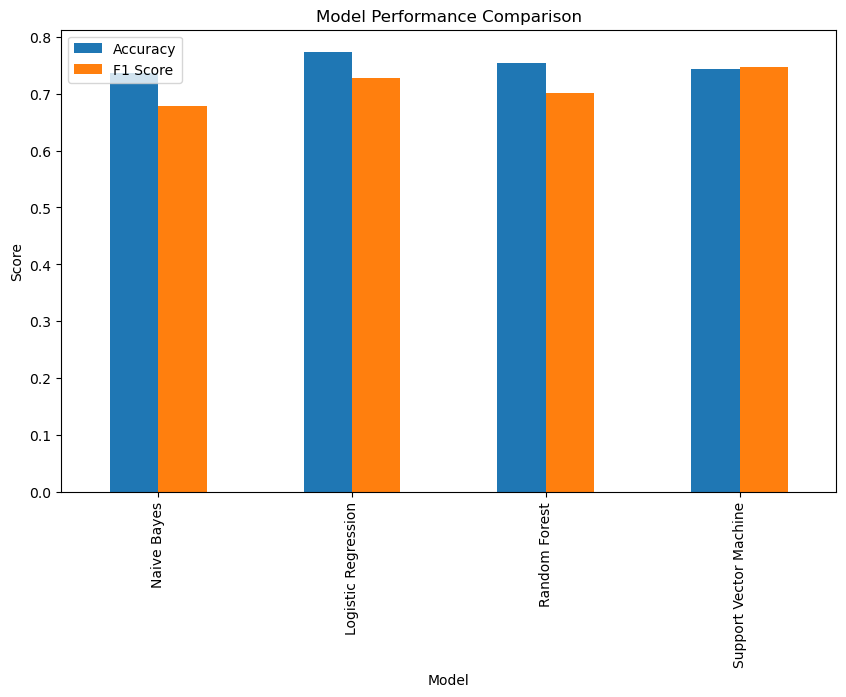

In [461]:
# Visual Comparison
comparison_df.set_index(
    'Model'
)[
    ['Accuracy','F1 Score']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Model Performance Comparison'
)

plt.ylabel('Score')

plt.show()

# Best Model Selection

In [462]:
# Find best model automatically
best_model_index = comparison_df[
    'F1 Score'
].idxmax()

best_model_name = comparison_df.loc[
    best_model_index,
    'Model'
]

print(
    "Best Model:",
    best_model_name
)

Best Model: Support Vector Machine


In [463]:
# Assigning best model
best_model = svm_model

# Saving Final Model

In [464]:
import joblib

joblib.dump(
    best_model,
    'sentiment_model.pkl'
)

joblib.dump(
    tfidf,
    'tfidf_vectorizer.pkl'
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


## Model Deployment

In [465]:
import pickle

# This code completely overwrites and fixes the broken file
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump({
        "vectorizer": tfidf, 
        "model": best_model, 
        "model_name": best_model_name
    }, f)

print("SUCCESS: Model saved cleanly and the broken file is now fixed!")

SUCCESS: Model saved cleanly and the broken file is now fixed!


In [466]:
# Creating the Pickle Model file
import pickle

# Load the single pickle file containing your dictionary
with open("sentiment_model.pkl", "rb") as f:
    saved_data = pickle.load(f)

# Unpack the components back into your variables
tfidf = saved_data["vectorizer"]
best_model = saved_data["model"]
best_model_name = saved_data["model_name"]

print("Model and vectorizer loaded successfully!")

Model and vectorizer loaded successfully!


In [467]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


---> App is successfully created in streamlit.